In [ ]:
import os, json, datetime, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers, Model
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

In [ ]:
# ── Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ══════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════
CONFIG = {
    "dataset_path": "/content/drive/MyDrive/DATASET",
    "output_dir": "/content/drive/MyDrive/DATASET/results",
    "image_size": (227, 227),
    "num_channels": 3,
    "num_classes": 5,
    "class_names": [
        "Mild-Demented", "Moderate-Demented", "Non-Demented",
        "Severe-Demented", "Very-Mild-Demented",
    ],
    "batch_size": 32,
    "epochs": 100,
    "initial_learning_rate": 1e-3,
    "min_learning_rate": 1e-7,
    "weight_decay": 5e-4,
    "dropout_fc1": 0.5,
    "dropout_fc2": 0.5,
    "label_smoothing": 0.1,
    "early_stopping_patience": 12,
    "reduce_lr_patience": 5,
    "reduce_lr_factor": 0.5,
    "seed": 42,
}

# ══════════════════════════════════════════════════════════════
# UTILITIES
# ══════════════════════════════════════════════════════════════

def set_seeds(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def separator(title):
    print(f"\n{'═'*72}\n  {title}\n{'═'*72}")

In [ ]:
# ══════════════════════════════════════════════════════════════
# STAGE 1 — DATASET INSPECTION
# ══════════════════════════════════════════════════════════════

def inspect_dataset(config):
    separator("STAGE 1 — DATASET INSPECTION")
    base = config["dataset_path"]
    class_names = config["class_names"]
    summary = {}

    for split in ["train", "valid"]:
        split_path = os.path.join(base, split)
        if not os.path.isdir(split_path):
            print(f"  [WARNING] Missing: {split_path}")
            continue

        print(f"\n  Split: {split}")
        print(f"  {'Class':<25} {'Count':>6}  {'%':>8}")
        print(f"  {'-'*42}")

        class_counts = {}
        total = 0
        for cls in class_names:
            cls_path = os.path.join(split_path, cls)
            if not os.path.isdir(cls_path):
                class_counts[cls] = 0
                continue
            files = [f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))]
            class_counts[cls] = len(files)
            total += len(files)

        for cls in class_names:
            cnt = class_counts.get(cls, 0)
            pct = (cnt / total * 100) if total > 0 else 0
            print(f"  {cls:<25} {cnt:>6}  {pct:>7.1f}%")
        print(f"  {'TOTAL':<25} {total:>6}")

        summary[split] = {"class_counts": class_counts, "total": total}

    return summary

In [ ]:
# ══════════════════════════════════════════════════════════════
# STAGE 2 — EXPLORATORY DATA ANALYSIS
# ══════════════════════════════════════════════════════════════

def perform_eda(config, inspection_summary):
    separator("STAGE 2 — EDA")
    out = os.path.join(config["output_dir"], "eda")
    ensure_dir(out)
    class_names = config["class_names"]
    palette = sns.color_palette("viridis", n_colors=config["num_classes"])

    # Class distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for idx, split in enumerate(["train", "valid"]):
        if split not in inspection_summary:
            continue
        counts = inspection_summary[split]["class_counts"]
        labels, values = list(counts.keys()), list(counts.values())
        bars = axes[idx].bar(labels, values, color=palette, edgecolor="black", linewidth=0.5)
        axes[idx].set_title(f"{split.capitalize()} — Class Distribution", fontsize=13, fontweight="bold")
        axes[idx].set_ylabel("Number of Images")
        axes[idx].tick_params(axis="x", rotation=35)
        for bar, v in zip(bars, values):
            axes[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                           str(v), ha="center", va="bottom", fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(out, "class_distribution.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Pixel intensity distribution
    pixel_values = {c: [] for c in class_names}
    for cls in class_names:
        cls_dir = os.path.join(config["dataset_path"], "train", cls)
        if not os.path.isdir(cls_dir): continue
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        chosen = np.random.choice(files, size=min(40, len(files)), replace=False)
        for f in chosen:
            img = np.array(Image.open(os.path.join(cls_dir, f)).convert("RGB"))
            pixel_values[cls].append(img.mean())

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, cls in enumerate(class_names):
        if pixel_values[cls]:
            ax.hist(pixel_values[cls], bins=25, alpha=0.55, label=cls, color=palette[i])
    ax.set_title("Mean Pixel Intensity Distribution (Train)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Mean Pixel Value (0-255)"); ax.set_ylabel("Frequency")
    ax.legend(fontsize=8); fig.tight_layout()
    fig.savefig(os.path.join(out, "pixel_intensity_distribution.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Sample images grid
    fig, axes = plt.subplots(2, config["num_classes"], figsize=(18, 7))
    for col, cls in enumerate(class_names):
        cls_dir = os.path.join(config["dataset_path"], "train", cls)
        if not os.path.isdir(cls_dir): continue
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        chosen = np.random.choice(files, size=min(2, len(files)), replace=False)
        for row, f in enumerate(chosen):
            img = Image.open(os.path.join(cls_dir, f)).convert("RGB")
            axes[row, col].imshow(img); axes[row, col].set_title(cls, fontsize=9)
            axes[row, col].axis("off")
    fig.suptitle("Sample Images per Class (Train)", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(out, "sample_images.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

In [ ]:
# ══════════════════════════════════════════════════════════════
# STAGE 3 — DATA LOADING
# ══════════════════════════════════════════════════════════════

def create_data_generators(config):
    separator("STAGE 3 — DATA LOADING")
    base = config["dataset_path"]

    # No augmentation — dataset is already augmented
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

    train_gen = datagen.flow_from_directory(
        os.path.join(base, "train"), target_size=config["image_size"],
        batch_size=config["batch_size"], class_mode="categorical",
        classes=config["class_names"], shuffle=True, seed=config["seed"],
    )
    valid_gen = datagen.flow_from_directory(
        os.path.join(base, "valid"), target_size=config["image_size"],
        batch_size=config["batch_size"], class_mode="categorical",
        classes=config["class_names"], shuffle=False, seed=config["seed"],
    )

    print(f"  Train batches/epoch : {len(train_gen)}")
    print(f"  Valid batches/epoch : {len(valid_gen)}")
    print(f"  Class indices       : {train_gen.class_indices}")
    return train_gen, valid_gen

In [ ]:
# ══════════════════════════════════════════════════════════════
# STAGE 4 — ALEXNET ARCHITECTURE
# ══════════════════════════════════════════════════════════════

def build_alexnet(config):
    separator("STAGE 4 — ALEXNET ARCHITECTURE")
    img_h, img_w = config["image_size"]
    wd = config["weight_decay"]
    l2 = regularizers.l2(wd)

    inputs = layers.Input(shape=(img_h, img_w, 3), name="input_image")

    # Block 1
    x = layers.Conv2D(96, (11,11), strides=4, padding="valid", kernel_regularizer=l2, name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation("relu", name="relu1")(x)
    x = layers.MaxPooling2D((3,3), strides=2, name="pool1")(x)

    # Block 2
    x = layers.Conv2D(256, (5,5), padding="same", kernel_regularizer=l2, name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation("relu", name="relu2")(x)
    x = layers.MaxPooling2D((3,3), strides=2, name="pool2")(x)

    # Block 3
    x = layers.Conv2D(384, (3,3), padding="same", kernel_regularizer=l2, name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.Activation("relu", name="relu3")(x)

    # Block 4
    x = layers.Conv2D(384, (3,3), padding="same", kernel_regularizer=l2, name="conv4")(x)
    x = layers.BatchNormalization(name="bn4")(x)
    x = layers.Activation("relu", name="relu4")(x)

    # Block 5
    x = layers.Conv2D(256, (3,3), padding="same", kernel_regularizer=l2, name="conv5")(x)
    x = layers.BatchNormalization(name="bn5")(x)
    x = layers.Activation("relu", name="relu5")(x)
    x = layers.MaxPooling2D((3,3), strides=2, name="pool5")(x)

    # FC layers
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(4096, kernel_regularizer=l2, name="fc1")(x)
    x = layers.BatchNormalization(name="bn_fc1")(x)
    x = layers.Activation("relu", name="relu_fc1")(x)
    x = layers.Dropout(config["dropout_fc1"], name="drop1")(x)

    x = layers.Dense(4096, kernel_regularizer=l2, name="fc2")(x)
    x = layers.BatchNormalization(name="bn_fc2")(x)
    x = layers.Activation("relu", name="relu_fc2")(x)
    x = layers.Dropout(config["dropout_fc2"], name="drop2")(x)

    outputs = layers.Dense(config["num_classes"], activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="AlexNet")
    model.summary()
    return model


In [ ]:
# ══════════════════════════════════════════════════════════════
# STAGE 5 — COMPILE & TRAIN
# ══════════════════════════════════════════════════════════════

def compile_and_train(model, train_gen, valid_gen, config):
    separator("STAGE 5 — TRAINING")
    out = config["output_dir"]
    ensure_dir(out)

    optimizer = optimizers.AdamW(
        learning_rate=config["initial_learning_rate"],
        weight_decay=config["weight_decay"],
    )
    loss_fn = keras.losses.CategoricalCrossentropy(
        label_smoothing=config["label_smoothing"],
    )
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    # Class weights
    from sklearn.utils.class_weight import compute_class_weight
    cw = compute_class_weight("balanced", classes=np.arange(config["num_classes"]), y=train_gen.classes)
    class_weight_dict = {i: w for i, w in enumerate(cw)}
    print(f"  Class weights: {class_weight_dict}")

    cb_list = [
        callbacks.EarlyStopping(monitor="val_loss", patience=config["early_stopping_patience"],
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=config["reduce_lr_factor"],
                                    patience=config["reduce_lr_patience"],
                                    min_lr=config["min_learning_rate"], verbose=1),
        callbacks.ModelCheckpoint(filepath=os.path.join(out, "best_model.keras"),
                                  monitor="val_loss", save_best_only=True, verbose=1),
        callbacks.CSVLogger(os.path.join(out, "training_log.csv"), separator=",", append=False),
    ]

    print(f"  Optimizer : AdamW (lr={config['initial_learning_rate']}, wd={config['weight_decay']})")
    print(f"  Loss      : CCE (label_smoothing={config['label_smoothing']})")
    print(f"  Epochs    : {config['epochs']} (max), Batch: {config['batch_size']}")

    history = model.fit(
        train_gen, validation_data=valid_gen, epochs=config["epochs"],
        callbacks=cb_list, class_weight=class_weight_dict, verbose=1,
    )
    return history

In [ ]:
# ══════════════════════════════════════════════════════════════
# STAGE 6 — EVALUATION
# ══════════════════════════════════════════════════════════════

def evaluate_model(model, valid_gen, config):
    separator("STAGE 6 — EVALUATION")
    class_names = config["class_names"]

    loss, accuracy = model.evaluate(valid_gen, verbose=0)
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")

    valid_gen.reset()
    y_pred_proba = model.predict(valid_gen, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = valid_gen.classes
    min_len = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:min_len], y_pred[:min_len]

    report_str = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n  Classification Report:\n{report_str}")

    cm = confusion_matrix(y_true, y_pred)
    print(f"  Confusion Matrix:\n{cm}")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(config["num_classes"]))

    results = {
        "test_loss": float(loss), "test_accuracy": float(accuracy),
        "classification_report": report_str, "confusion_matrix": cm.tolist(),
        "per_class": {},
    }
    for i, cls in enumerate(class_names):
        results["per_class"][cls] = {
            "precision": float(precision[i]), "recall": float(recall[i]),
            "f1_score": float(f1[i]), "support": int(support[i]),
        }
    return results

In [ ]:
# ══════════════════════════════════════════════════════════════
# STAGE 7 — VISUALIZATION
# ══════════════════════════════════════════════════════════════

def plot_training_curves(history, config):
    separator("STAGE 7 — VISUALIZATION")
    out = os.path.join(config["output_dir"], "plots")
    ensure_dir(out)
    epochs_ran = range(1, len(history.history["loss"]) + 1)

    # Loss curves
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs_ran, history.history["loss"], label="Train Loss", lw=2, color="#3b82f6")
    ax.plot(epochs_ran, history.history["val_loss"], label="Val Loss", lw=2, color="#ef4444", ls="--")
    ax.set_title("Training & Validation Loss", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, "loss_curves.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Accuracy curves
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs_ran, history.history["accuracy"], label="Train Acc", lw=2, color="#22c55e")
    ax.plot(epochs_ran, history.history["val_accuracy"], label="Val Acc", lw=2, color="#f97316", ls="--")
    ax.set_title("Training & Validation Accuracy", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, "accuracy_curves.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Combined
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(epochs_ran, history.history["loss"], label="Train", lw=2, color="#3b82f6")
    ax1.plot(epochs_ran, history.history["val_loss"], label="Val", lw=2, color="#ef4444", ls="--")
    ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs_ran, history.history["accuracy"], label="Train", lw=2, color="#22c55e")
    ax2.plot(epochs_ran, history.history["val_accuracy"], label="Val", lw=2, color="#f97316", ls="--")
    ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)
    fig.suptitle("AlexNet Training Summary", fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(out, "training_summary.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)


def plot_confusion_matrix(results, config):
    out = os.path.join(config["output_dir"], "plots")
    ensure_dir(out)
    cm = np.array(results["confusion_matrix"])
    class_names = config["class_names"]

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor="gray", ax=ax)
    ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    plt.xticks(rotation=35, ha="right"); plt.yticks(rotation=0)
    fig.tight_layout(); fig.savefig(os.path.join(out, "confusion_matrix.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Normalized
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor="gray", ax=ax, vmin=0, vmax=1)
    ax.set_title("Normalized Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    plt.xticks(rotation=35, ha="right"); plt.yticks(rotation=0)
    fig.tight_layout(); fig.savefig(os.path.join(out, "confusion_matrix_normalized.png"), dpi=150)
    plt.show(); plt.close(fig)


In [ ]:
# ══════════════════════════════════════════════════════════════
# STAGE 8 — SAVE MODEL & RESULTS
# ══════════════════════════════════════════════════════════════

def save_everything(model, history, results, config):
    separator("STAGE 8 — SAVING ARTEFACTS")
    out = config["output_dir"]
    ensure_dir(out)

    # Full model
    model.save(os.path.join(out, "alexnet_final.keras"))
    print(f"  ✓ Final model saved")

    # Weights
    model.save_weights(os.path.join(out, "alexnet_weights.weights.h5"))
    print(f"  ✓ Weights saved")

    # Architecture JSON
    with open(os.path.join(out, "alexnet_architecture.json"), "w") as f:
        json.dump(json.loads(model.to_json()), f, indent=2)
    print(f"  ✓ Architecture JSON saved")

    # Training history
    hist_data = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(os.path.join(out, "training_history.json"), "w") as f:
        json.dump(hist_data, f, indent=2)
    print(f"  ✓ Training history saved")

    # Evaluation results
    with open(os.path.join(out, "evaluation_results.json"), "w") as f:
        json.dump(results, f, indent=2)
    print(f"  ✓ Evaluation results saved")

    # Config snapshot
    config_safe = {k: v for k, v in config.items()}
    config_safe["timestamp"] = datetime.datetime.now().isoformat()
    with open(os.path.join(out, "config_snapshot.json"), "w") as f:
        json.dump(config_safe, f, indent=2)
    print(f"  ✓ Config snapshot saved")

╔══════════════════════════════════════════════════════════════╗
║  AlexNet — Dementia MRI Classification (Colab + GPU)       ║
║  5 Classes · 227×227 · TensorFlow/Keras                    ║
╚══════════════════════════════════════════════════════════════╝

  TensorFlow : 2.19.0
  GPUs       : 1
    • /physical_device:GPU:0

════════════════════════════════════════════════════════════════════════
  STAGE 1 — DATASET INSPECTION
════════════════════════════════════════════════════════════════════════

  Split: train
  Class                      Count         %
  ------------------------------------------
  Mild-Demented               1000     20.0%
  Moderate-Demented           1000     20.0%
  Non-Demented                1000     20.0%
  Severe-Demented             1000     20.0%
  Very-Mild-Demented          1000     20.0%
  TOTAL                       5000

  Split: valid
  Class                      Count         %
  ------------------------------------------
  Mild-Demented          

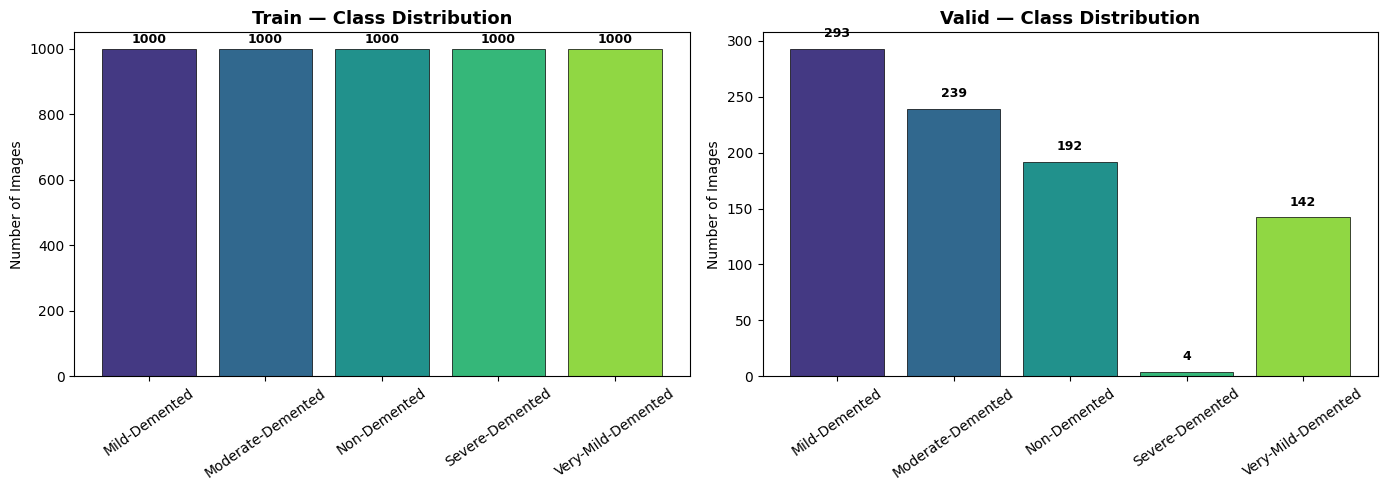

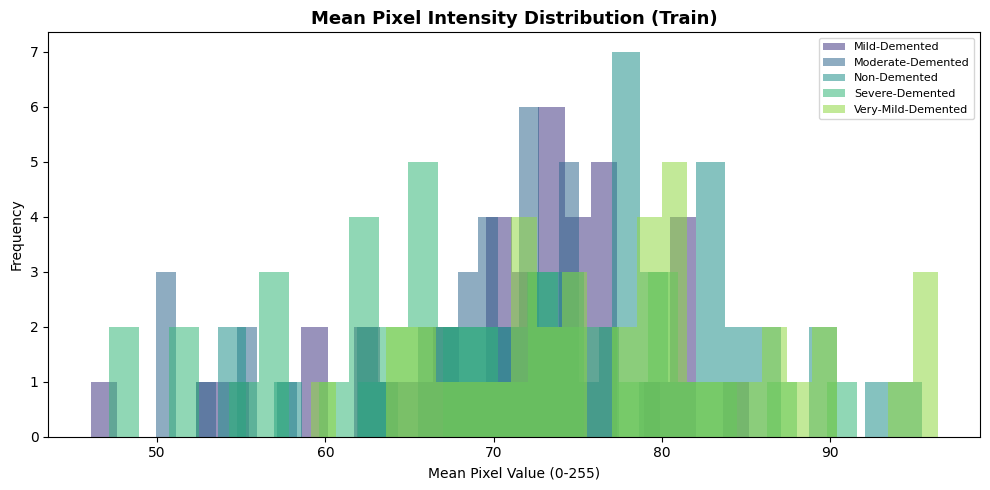

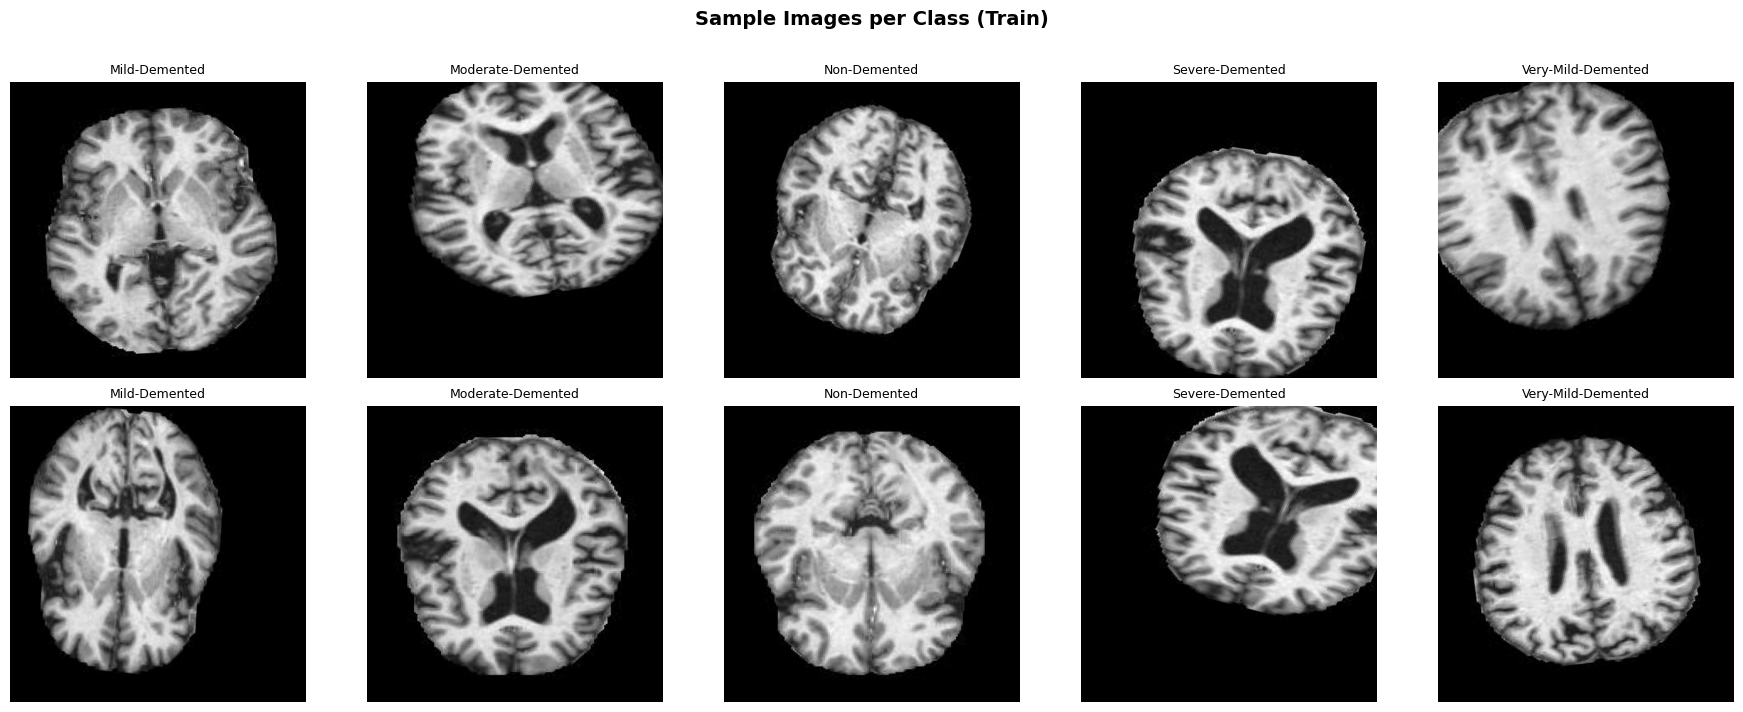


════════════════════════════════════════════════════════════════════════
  STAGE 3 — DATA LOADING
════════════════════════════════════════════════════════════════════════
Found 5000 images belonging to 5 classes.
Found 870 images belonging to 5 classes.
  Train batches/epoch : 157
  Valid batches/epoch : 28
  Class indices       : {'Mild-Demented': 0, 'Moderate-Demented': 1, 'Non-Demented': 2, 'Severe-Demented': 3, 'Very-Mild-Demented': 4}

════════════════════════════════════════════════════════════════════════
  STAGE 4 — ALEXNET ARCHITECTURE
════════════════════════════════════════════════════════════════════════


Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 55, 55, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 55, 55, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 27, 27, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 13, 13, 384)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 13, 13, 384)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 13, 13, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (Activation)              │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc1 (BatchNormalization)     │ (None, 4096)           │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_fc1 (Activation)           │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 58,340,101 (222.55 MB)

 Trainable params: 58,320,965 (222.48 MB)

 Non-trainable params: 19,136 (74.75 KB)


════════════════════════════════════════════════════════════════════════
  STAGE 5 — TRAINING
════════════════════════════════════════════════════════════════════════
  Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}
  Optimizer : AdamW (lr=0.001, wd=0.0005)
  Loss      : CCE (label_smoothing=0.1)
  Epochs    : 100 (max), Batch: 32
Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6290 - loss: 7.6919
Epoch 1: val_loss improved from inf to 16.97142, saving model to /content/drive/MyDrive/DATASET/results/best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.6297 - loss: 7.6871 - val_accuracy: 0.2218 - val_loss: 16.9714 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8638 - loss: 5.1075
Epoch 2: val_loss improved from 16.97142 to 4.26423, saving model to /content/drive/MyDrive/DATASET/results/best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 4

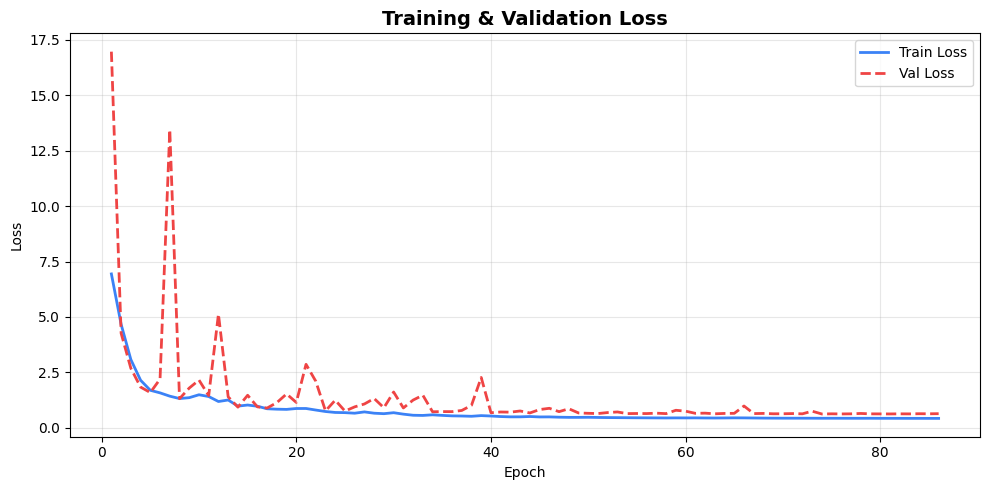

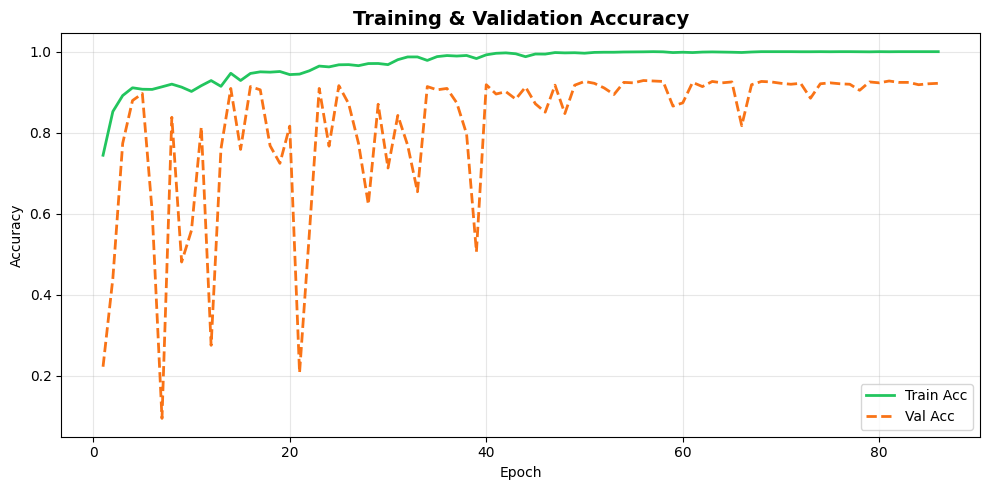

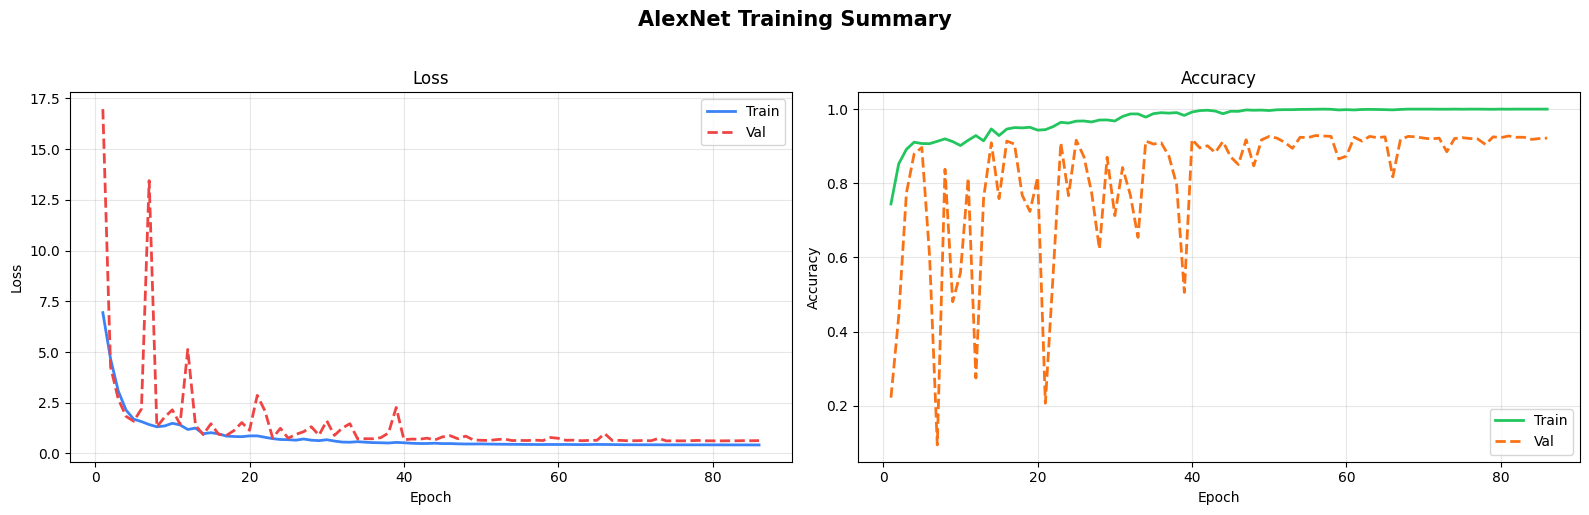

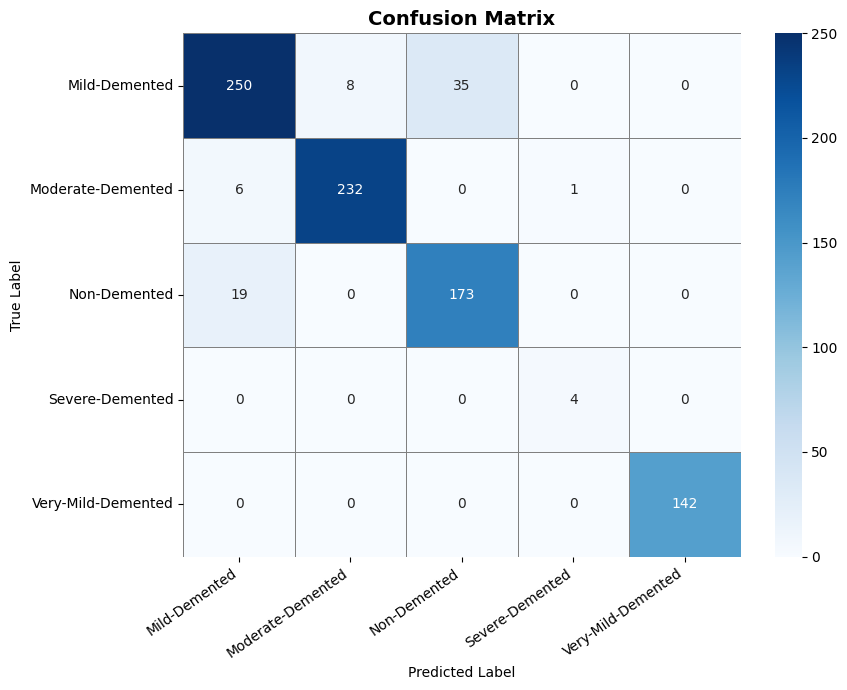

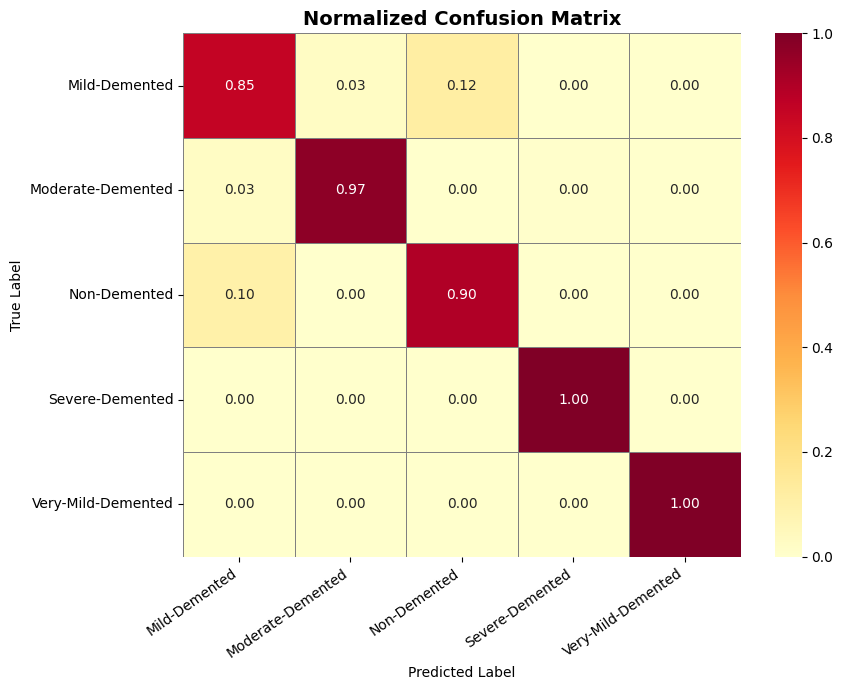


════════════════════════════════════════════════════════════════════════
  STAGE 8 — SAVING ARTEFACTS
════════════════════════════════════════════════════════════════════════
  ✓ Final model saved
  ✓ Weights saved
  ✓ Architecture JSON saved
  ✓ Training history saved
  ✓ Evaluation results saved
  ✓ Config snapshot saved

════════════════════════════════════════════════════════════════════════
  PIPELINE COMPLETE
════════════════════════════════════════════════════════════════════════
  Final Test Accuracy : 92.07%
  Final Test Loss     : 0.6205
  All outputs saved to: /content/drive/MyDrive/DATASET/results


In [ ]:
# ══════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ══════════════════════════════════════════════════════════════

def main():
    print("╔══════════════════════════════════════════════════════════════╗")
    print("║  AlexNet — Dementia MRI Classification (Colab + GPU)       ║")
    print("║  5 Classes · 227×227 · TensorFlow/Keras                    ║")
    print("╚══════════════════════════════════════════════════════════════╝")

    set_seeds(CONFIG["seed"])

    # GPU check
    gpus = tf.config.list_physical_devices("GPU")
    print(f"\n  TensorFlow : {tf.__version__}")
    print(f"  GPUs       : {len(gpus)}")
    for g in gpus: print(f"    • {g.name}")

    # Run pipeline
    inspection = inspect_dataset(CONFIG)
    perform_eda(CONFIG, inspection)
    train_gen, valid_gen = create_data_generators(CONFIG)
    model = build_alexnet(CONFIG)
    history = compile_and_train(model, train_gen, valid_gen, CONFIG)
    results = evaluate_model(model, valid_gen, CONFIG)
    plot_training_curves(history, CONFIG)
    plot_confusion_matrix(results, CONFIG)
    save_everything(model, history, results, CONFIG)

    separator("PIPELINE COMPLETE")
    print(f"  Final Test Accuracy : {results['test_accuracy']*100:.2f}%")
    print(f"  Final Test Loss     : {results['test_loss']:.4f}")
    print(f"  All outputs saved to: {CONFIG['output_dir']}")

if __name__ == "__main__":
    main()